In [1]:
%matplotlib inline

import os, warnings

import numpy as np
import scipy as sp
import pandas as pd
from tqdm import tqdm
import bct
import networkx as nx

import torch
from src.utils import get_weight_masks, get_weight_masks_schaefer, get_file_str, normalize_x

# import plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
save_figs = True

In [3]:
# directories
tracto_string = 'deterministic_count'
# tracto_string = 'deterministic_ncount'
# tracto_string = 'deterministic_mean_length'
# tracto_string = 'deterministic_gfa'
# tracto_string = 'probabilistic_sift_radius2'
datadir = '/home/lindenmp/research_projects/neuro_rnn/data/{0}'.format(tracto_string)
modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/model'
outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

# data parameters
# task = 'PerceptualDecisionMaking-v0'
# task = 'MultiSensoryIntegration-v0'
task = 'ContextDecisionMaking-v0'
dt = 100
batch_size = 128
decision = 300
seq_len = 13
seq_len = seq_len + int((decision - 100) / dt)
seq_len = seq_len * 2
print(seq_len)

# RNN model and training parameters
rnn_model = 'rnn-tanh'
hidden_size = 100
n_runs = 25
n_epochs = 10000
lr = 0.001

# regularization parameters
reg_type = 'l2'
reg_weight = 0.001
mask_weights = True
kernel_type = 'sa_axis'
# kernel_type = 'euclidean'
# kernel_type = None

if mask_weights and hidden_size == 50:
    n_io = '9-13'
if mask_weights and hidden_size == 100:
    n_io = '14-27'
if mask_weights and hidden_size == 200:
    n_io = '31-52'

30


In [4]:
timing = {'decision': decision}
env_kwargs = {'dt': dt, 'timing': timing}

config = {
    'datadir': datadir, 'outdir': outdir,
    'task': task, 'dt': dt, 'seq_len': seq_len, 'batch_size': batch_size,  # data parameters
    'rnn_model': rnn_model, 'hidden_size': hidden_size, 'n_runs': n_runs, 'n_epochs': n_epochs, 'lr': lr, 'mask_weights': mask_weights,  # RNN model and training parameters
    'reg_type': reg_type, 'reg_weight': reg_weight, 'kernel_type': kernel_type, # regularization parameters
    'env_kwargs': env_kwargs,
}

In [5]:
# weight masks
if mask_weights:
    centroids = pd.read_csv(os.path.join(datadir, 'schaefer{0}_centroids.csv'.format(hidden_size * 2)))
    centroids = centroids[:hidden_size]
    roi_names = list(centroids['ROI Name'])
    input_system = 'Vis'
    output_system = 'Default'
    masks = get_weight_masks_schaefer(roi_names=roi_names, input_system=input_system, output_system=output_system)
    n_io = '{0}-{1}'.format(np.sum(masks['input_weight_mask']), np.sum(masks['output_weight_mask']))
else:
    n_io = 'na'
config['n_io'] = n_io

file_str = get_file_str(config)
print(file_str)

task-ContextDecisionMaking-v0-30-128-300_model-rnn-tanh-100-14-27-25-10000-0.001_wmask-True_reg-l2-0.001-sa_axis


In [6]:
# Device configuration
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

In [7]:
# load data
log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True).item()
training_loss = log_args['training_loss']
validation_loss = log_args['validation_loss']
test_accuracy = log_args['test_accuracy']
n_logged_epochs = test_accuracy.shape[-1]
x_step = int(n_epochs / (n_logged_epochs-1))

checkpoint = torch.load(os.path.join(modeldir, file_str + '.pt'), map_location=device)
hidden_weights = np.zeros((n_runs, n_logged_epochs, hidden_size, hidden_size))
for i, run in enumerate(checkpoint.keys()):
    for j, epoch in enumerate(checkpoint[run].keys()):
        hidden_weights[i, j] = checkpoint[run][epoch]['rnn.weight_hh_l0']
del checkpoint

print(training_loss.shape)
print(validation_loss.shape)
print(test_accuracy.shape)
print(hidden_weights.shape)
print(n_logged_epochs)

(25, 10000)
(25, 10000)
(25, 101)
(25, 101, 100, 100)
101


### Connectome weights

In [8]:
n_parcels = int(hidden_size * 2)
modality = 'A'
# modality = 'rsfc'

dataset = 'pnc'
A_pnc = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_{2}.npy').format(dataset, n_parcels, modality))
A_pnc = A_pnc[:hidden_size, :hidden_size, :]
Am_pnc = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_Am.npy').format(dataset, n_parcels))
Am_pnc = Am_pnc[:hidden_size, :hidden_size]
df_pnc = pd.read_csv(os.path.join(datadir, '{0}_schaefer{1}-7_df.csv').format(dataset, n_parcels), index_col=0)

if tracto_string != 'probabilistic_sift_radius2':
    dataset = 'hbn'
    A_hbn = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_{2}.npy').format(dataset, n_parcels, modality))
    A_hbn = A_hbn[:hidden_size, :hidden_size, :]
    Am_hbn = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_Am.npy').format(dataset, n_parcels))
    Am_hbn = Am_hbn[:hidden_size, :hidden_size]
    df_hbn = pd.read_csv(os.path.join(datadir, '{0}_schaefer{1}-7_df.csv').format(dataset, n_parcels), index_col=0)

    dataset = 'hcpd'
    A_hcpd = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_{2}.npy').format(dataset, n_parcels, modality))
    A_hcpd = A_hcpd[:hidden_size, :hidden_size, :]
    Am_hcpd = np.load(os.path.join(datadir, '{0}_schaefer{1}-7_Am.npy').format(dataset, n_parcels))
    Am_hcpd = Am_hcpd[:hidden_size, :hidden_size]
    df_hcpd = pd.read_csv(os.path.join(datadir, '{0}_schaefer{1}-7_df.csv').format(dataset, n_parcels), index_col=0)

In [9]:
dataset = 'pnc'
# dataset = 'hbn'
# dataset = 'hcpd'
if dataset == 'pnc':
    Am_human = Am_pnc
    A_human = A_pnc
    df_human = df_pnc
elif dataset == 'hbn':
    Am_human = Am_hbn
    A_human = A_hbn
    df_human = df_hbn

    df_human = df_human[df_hbn['study_site'] == 'HBN-1']
    A_human = A_human[:, :, df_hbn['study_site'] == 'HBN-1']
    # df_human = df_human[df_hbn['study_site'] == 'HBN-3']
    # A_human = A_human[:, :, df_hbn['study_site'] == 'HBN-3']
    # df_human = df_human[df_hbn['study_site'] == 'HBN-4']
    # A_human = A_human[:, :, df_hbn['study_site'] == 'HBN-4']
elif dataset == 'hcpd':
    Am_human = Am_hcpd
    A_human = A_hcpd
    df_human = df_hcpd
else:
    cols = ['age', 'sex', 'site']
    df_human = pd.concat((df_pnc[cols], df_hbn[cols], df_hcpd[cols]), axis=0)
    A_human = np.concatenate((A_pnc, A_hbn, A_hcpd), axis=2)

print(A_human.shape, df_human.shape)
print(df_human['age'].describe())
n_subjects = A_human.shape[-1]

(100, 100, 912) (912, 23)
count    912.000000
mean      15.357091
std        3.395036
min        8.166667
25%       12.833333
50%       15.583333
75%       18.000000
max       23.000000
Name: age, dtype: float64


In [10]:
subj_filter = np.zeros(n_subjects).astype(bool)
for i in np.arange(n_subjects):
    if np.all(A_human[:, :, i] == 0):
        subj_filter[i] = True

    if np.any(np.isnan(A_human[:, :, i])):
        subj_filter[i] = True

    if np.any(np.isinf(A_human[:, :, i])):
        subj_filter[i] = True

    if np.std(A_human[:, :, i]) == 0:
        subj_filter[i] = True

    if bct.density_und(A_human[:,:,i])[0] < .001:
        subj_filter[i] = True

In [11]:
if np.any(subj_filter):
    df_human = df_human[~subj_filter]
    A_human = A_human[:, :, ~subj_filter]
    print(A_human.shape, df_human.shape)
    print(df_human['age'].describe())
    n_subjects = A_human.shape[-1]

### RNN weights

# Stats

In [12]:
from numba import njit

@njit
def get_mean(x):
    n = len(x)
    m = np.empty(n)
    for i in range(n):
        m[i] = x[i].mean()
    return m

@njit
def get_std(x):
    n = len(x)
    s = np.empty(n)
    for i in range(n):
        s[i] = x[i].std()
    return s

@njit
def get_corr_fast(x, y):
    ''' Correlation '''
    n, k = x.shape
    m, k = y.shape

    mu_a = get_mean(x)
    mu_b = get_mean(y)
    sig_a = get_std(x)
    sig_b = get_std(y)

    corr_coef = np.empty((n, m))

    for i in range(n):
        for j in range(m):
            corr_coef[i, j] = (x[i] - mu_a[i]) @ (y[j] - mu_b[j]) / k / sig_a[i] / sig_b[j]

    return corr_coef

In [13]:
df_human['age_group'] = np.zeros(n_subjects)
n_quantiles = 10
quantiles = np.linspace(0, 1, n_quantiles+1)[1:]
print(quantiles)
for i, q in enumerate(quantiles):
    thresh = np.quantile(df_human['age'], q=q)
    if i == 0:
        mask = df_human['age'] <= thresh
    else:
        mask = np.logical_and(df_human['age'] <= thresh, df_human['age'] > previous_thresh)
    df_human.loc[mask, 'age_group'] = i
    previous_thresh = thresh

print(df_human.groupby('age_group')['age'].count())
print(df_human.groupby('age_group')['age'].mean())

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
age_group
0.0    94
1.0    90
2.0    94
3.0    93
4.0    86
5.0    91
6.0    90
7.0    97
8.0    88
9.0    89
Name: age, dtype: int64
age_group
0.0     9.432624
1.0    11.332407
2.0    12.810284
3.0    14.055556
4.0    15.213178
5.0    16.147436
6.0    17.066667
7.0    18.059278
8.0    19.088068
9.0    20.702247
Name: age, dtype: float64


<Axes: >

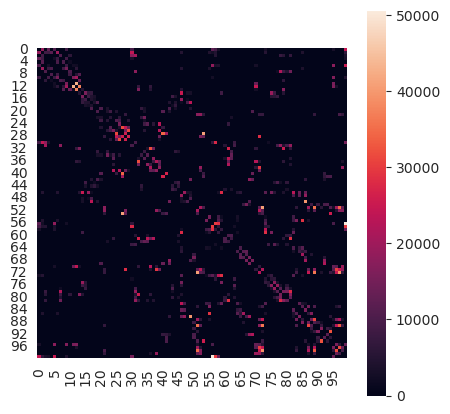

In [14]:
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(Am_human, ax=ax, square=True)

In [15]:
# which_feature = 'edge'
which_feature = 'strength'

if which_feature == 'edge':
    weight_mask = Am_human > 0
    n_features = np.sum(weight_mask)
    print(np.sum(weight_mask))
    rnn_features_rank = np.zeros((n_runs, n_logged_epochs, n_features))
    for run in tqdm(np.arange(n_runs)):
        for epoch in np.arange(n_logged_epochs):
            A = np.abs(hidden_weights[run, epoch]).copy()
            A = (A + A.T) / 2
            A = A / np.linalg.norm(A)
            rnn_features_rank[run, epoch, :] = sp.stats.rankdata(A[weight_mask])

    human_features_rank = np.zeros((n_subjects, n_features))
    for subj in np.arange(n_subjects):
        A = A_human[:, :, subj].copy()
        A = A / np.linalg.norm(A)
        human_features_rank[subj, :] = sp.stats.rankdata(A[weight_mask])
elif which_feature == 'strength':
    n_features = hidden_size
    rnn_features_rank = np.zeros((n_runs, n_logged_epochs, n_features))
    for run in tqdm(np.arange(n_runs)):
        for epoch in np.arange(n_logged_epochs):
            A = np.abs(hidden_weights[run, epoch]).copy()
            rnn_features_rank[run, epoch, :] = sp.stats.rankdata(bct.strengths_dir(A))

    human_features_rank = np.zeros((n_subjects, n_features))
    for subj in np.arange(n_subjects):
        A = A_human[:, :, subj].copy()
        human_features_rank[subj, :] = sp.stats.rankdata(bct.strengths_und(A))

abs_weight_corr_r = np.zeros((n_runs, n_logged_epochs, n_subjects))
for run in tqdm(np.arange(n_runs)):
    abs_weight_corr_r[run] = get_corr_fast(rnn_features_rank[run, :, :], human_features_rank)

abs_weight_corr_r_mean = np.mean(abs_weight_corr_r, axis=0)
abs_weight_corr_r_mean_group = np.zeros((n_logged_epochs, n_quantiles))
for group in np.arange(n_quantiles):
    abs_weight_corr_r_mean_group[:, group] = np.median(abs_weight_corr_r_mean[:, df_human['age_group'] == group], axis=1)

age_corr = np.zeros((n_runs, n_logged_epochs))
for run in tqdm(np.arange(n_runs)):
    age_corr[run] = get_corr_fast(df_human['age'].values.reshape(1, -1), abs_weight_corr_r[run])

print(rnn_features_rank.shape, human_features_rank.shape, abs_weight_corr_r.shape, abs_weight_corr_r_mean_group.shape, age_corr.shape)

100%|██████████| 25/25 [00:00<00:00, 7113.33it/s]

(25, 101, 100) (912, 100) (25, 101, 912) (101, 10) (25, 101)


In [16]:
# f, ax = plt.subplots(2, 4, figsize=(10, 5))
# # A = np.abs(hidden_weights[0, 50]).copy()
# A = np.abs(hidden_weights[:, 50]).copy()
# if A.ndim == 3:
#     A = np.mean(A, axis=0)
# # A = (A + A.T) / 2
# # A = A / np.linalg.norm(A)
# print(A.shape)
#
# for i, subj in enumerate([0, 100, 200, 300]):
#     my_reg_plot(x=np.mean(rnn_features_rank, axis=0)[50, :], y=human_features_rank[subj, :], xlabel='RNN weights', ylabel='connectome weights', ax=ax[0, i], annotate='both')
#     my_reg_plot(x=bct.strengths_dir(A), y=bct.strengths_und(A_human[:, :, subj]), xlabel='RNN weights', ylabel='connectome weights', ax=ax[1, i], annotate='both')
#
# f.tight_layout()
# plt.show()

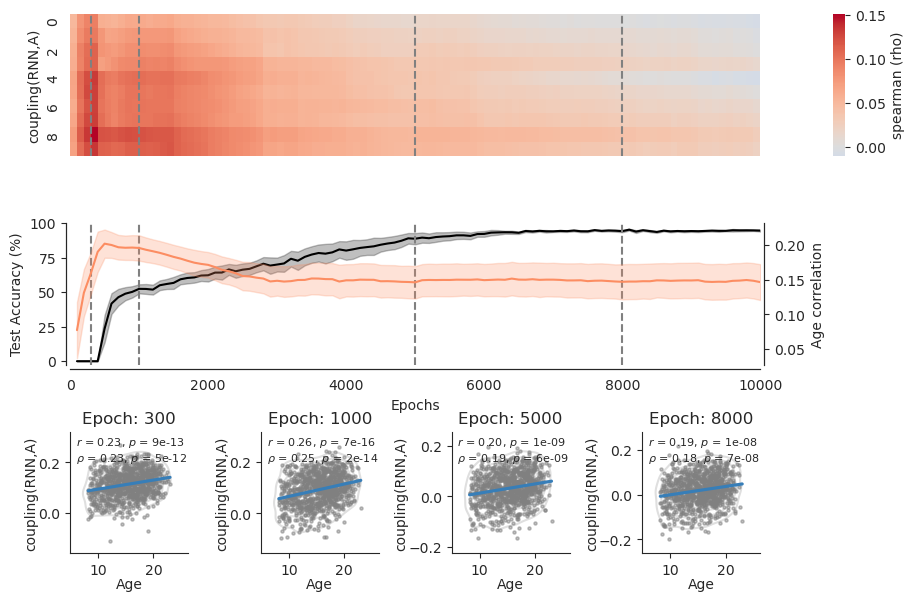

In [17]:
fig_width = 10
fig_height = 7
f = plt.figure(layout=None, figsize=(fig_width, fig_height))
cbar_width = 2.5
column_width = (100 - cbar_width) / 4
gs = f.add_gridspec(nrows=3, ncols=5, hspace=0.5, wspace=0.75,
                    height_ratios=[0.35, 0.35, 0.3],
                    width_ratios=[column_width, column_width, column_width, column_width, cbar_width])
ax0 = f.add_subplot(gs[0, :-1])
ax0_cbar = f.add_subplot(gs[0, -1])
ax1 = f.add_subplot(gs[1, :-1])
ax1_twin = ax1.twinx()
ax2_0 = f.add_subplot(gs[2, 0])
ax2_1 = f.add_subplot(gs[2, 1])
ax2_2 = f.add_subplot(gs[2, 2])
ax2_3 = f.add_subplot(gs[2, 3])

indices = [3, 10, 50, 80]
n_indices = len(indices)
ax2_list = [ax2_0, ax2_1, ax2_2, ax2_3]

color_palette = sns.color_palette("Set2")
x_step = int(n_epochs / (n_logged_epochs-1))
x = np.arange(x_step, n_epochs + x_step, x_step)

# row 0
sns.heatmap(abs_weight_corr_r_mean_group[1:, :].T, ax=ax0, square=False, cmap='coolwarm', center=0, cbar_ax=ax0_cbar, cbar_kws={'label': 'spearman (rho)'})
# age_idx = np.argsort(df_human['age'])
# sns.heatmap(abs_weight_corr_r_mean[1:, age_idx].T, ax=ax0, square=False, cmap='coolwarm', center=0, cbar_ax=ax0_cbar, cbar_kws={'label': 'spearman (rho)'})
ax0.set_ylabel('coupling(RNN,A)')
for epoch in np.arange(n_indices):
    ax0.axvline(indices[epoch], color='gray', linestyle='--')
ax0.set_xticklabels('')

# row 1
accuracy_mean = test_accuracy.mean(axis=0)[1:]*100
accuracy_std = test_accuracy.std(axis=0)[1:]*100
ci = 1.96 * (accuracy_std / np.sqrt(n_runs))
accuracy_ci_lower = accuracy_mean - ci
accuracy_ci_upper = accuracy_mean + ci

corr_mean = age_corr.mean(axis=0)[1:]
corr_std = age_corr.std(axis=0)[1:]
ci = 1.96 * (corr_std / np.sqrt(n_runs))
corr_ci_lower = corr_mean - ci
corr_ci_upper = corr_mean + ci

ax1.plot(x, accuracy_mean, color='k', label='Accuracy')
ax1.fill_between(x, accuracy_ci_lower, accuracy_ci_upper, color='k', alpha=0.25)
ax1.set_ylim([-2.5, 100])
ax1.set_xlim([0, 10000])
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_xlabel('Epochs')
for epoch in np.arange(n_indices):
    ax1.axvline(indices[epoch]*100, color='gray', linestyle='--')

ax1_twin.plot(x, corr_mean, color=color_palette[1], label='Accuracy')
ax1_twin.fill_between(x, corr_ci_lower, corr_ci_upper, color=color_palette[1], alpha=0.25)
ax1_twin.set_ylabel('Age correlation')

for this_ax in [ax1, ax1_twin]:
    sns.despine(offset=3, trim=False, left=False, right=False, top=True, bottom=False, ax=this_ax)

# row 2
for epoch in np.arange(n_indices):
    # run = np.argmin(np.abs(age_corr[:, indices[epoch]] - age_corr[:, indices[epoch]].mean()))
    # my_reg_plot(x=df_human['age'], y=abs_weight_corr_r[run, indices[epoch]],
    my_reg_plot(x=df_human['age'], y=np.mean(abs_weight_corr_r[:, indices[epoch]], axis=0),
                xlabel='Age', ylabel='coupling(RNN,A)', ax=ax2_list[epoch], annotate='both')
    sns.despine(offset=0, trim=False, left=False, right=True, top=True, bottom=False, ax=ax2_list[epoch])
    ax2_list[epoch].set_title('Epoch: {0}'.format(indices[epoch]*100))

plt.show()
f.savefig(os.path.join(outdir, '{0}_corr(RNN,{1}).png'.format(file_str, dataset)), dpi=300, bbox_inches='tight', pad_inches=0.01)